# Grouping Comparison Experiment

Runs each grouping method sequentially on the held-out test scenarios
(`fox`, `russellmitchell`), computes the three comparison metrics
(alert volume reduction, group size distribution, group purity) for
every method/hyperparameter setting, plots per-method diagnostics as it
goes, and produces the final cross-method comparison plots at the end.

**Before running:** fill in `load_scenario_alerts()` in the Setup section
to hook into your actual data loader. Every alert object must expose
`alert_id`, `ts`, `host`, `signature`, and a label field (default assumed
name: `time_label`) with values distinguishing benign vs attack.


## 1. Imports

In [15]:
from __future__ import annotations

import math
import time
import itertools
from dataclasses import dataclass, field
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thesis.grouping.group_alerts import (
    group_alerts_fixed_window,
    group_alerts_fixed_window_host,
    group_alerts_time_delta,
    group_alerts_time_delta_host,
    group_alerts_cscas,
    group_alerts_alertbert,
    CSCAS_SESSION_LENGTH_SECONDS,
    CSCAS_SESSION_TIMEOUT_SECONDS,
)
from thesis.grouping.deepcase_grouping import (
    group_alerts_deepcase_many_eps,
    train_id_for_scenarios,
)


## 2. Setup

- `TEST_SCENARIOS`: the held-out scenarios grouping metrics are reported on.
  Keep this fixed across every method for a fair comparison.
- `LABEL_FIELD`: attribute name on each alert holding its benign/attack label.
- `load_scenario_alerts`: **fill this in** to return a list of alert objects
  (matching the `GroupableAlert` protocol) for a given scenario, already
  sorted or unsorted (grouping functions sort internally where needed).


In [16]:
from thesis.grouping.window_sweep import load_and_tokenize

TEST_SCENARIOS = ["fox", "russellmitchell"]
LABEL_FIELD = "label"     # IncomingAlert/TokenizedAlert rename the raw "time_label" CSV column to "label"
BENIGN_LABELS = {"false_positive"}   # only value marking benign in this dataset's label vocabulary


def load_scenario_alerts(scenario: str) -> list:
    """
    Loads and tokenizes raw alerts for a scenario, matching the GroupableAlert
    protocol (alert_id, ts, host, signature) plus a label field for purity checks.
    Cached to artifacts/cache/{scenario}/alerts/tokenized_raw.json after first run.
    """
    return load_and_tokenize(scenario)


# Preload alerts for all test scenarios once, and an alert_id -> alert index
# for fast label lookups when computing purity.
alerts_by_scenario = {s: load_scenario_alerts(s) for s in TEST_SCENARIOS}
alert_index_by_scenario = {
    s: {a.alert_id: a for a in alerts} for s, alerts in alerts_by_scenario.items()
}

# DeepCASE trains its own ContextBuilder on the *train*-scenario alerts
# (no pretrained checkpoint exists for this dataset, unlike AlertBERT) --
# these have no tokenized_raw.json cache yet, unlike fox/russellmitchell,
# so the first run tokenizes all 4 from raw .txt (real one-time cost).
DEEPCASE_TRAIN_SCENARIOS = ["shaw", "wardbeck", "wheeler", "wilson"]
deepcase_train_alerts_by_scenario = {
    s: load_scenario_alerts(s) for s in DEEPCASE_TRAIN_SCENARIOS
}
deepcase_train_alerts = [
    a for s in DEEPCASE_TRAIN_SCENARIOS for a in deepcase_train_alerts_by_scenario[s]
]
# Canonical, order-independent cache key -- see train_id_for_scenarios's
# docstring for why this matters (an ad hoc string either fragments the
# cache or silently reuses a stale model).
DEEPCASE_TRAIN_ID = train_id_for_scenarios(DEEPCASE_TRAIN_SCENARIOS)
len(deepcase_train_alerts), DEEPCASE_TRAIN_ID


  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/fox/alerts/tokenized_raw.json
  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/russellmitchell/alerts/tokenized_raw.json
  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/shaw/alerts/tokenized_raw.json
  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/wardbeck/alerts/tokenized_raw.json
  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/wheeler/alerts/tokenized_raw.json
  [cache] Loading tokenized alerts from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/wilson/alerts/tokenized_raw.json


(1412446, 'shaw+wardbeck+wheeler+wilson')

## 3. Metric functions

### Schema addition: `is_outlier`

Coverage (below) needs to distinguish "this alert is the sole member of a real group" from "this alert was rejected and never grouped at all" -- DeepCASE specifically has a genuine rejection path (DBSCAN noise, or the Context Builder's confidence never clearing `threshold`), and the two cases are indistinguishable after the fact if both just look like a group of size 1.

`GroupingRecord` (`thesis/schemas/groups.py`) now has an `is_outlier: bool = False` field, and `group_alerts_deepcase_many_eps` (`thesis/grouping/deepcase_grouping.py`, via `_cluster_ids_to_records`) sets `is_outlier=True` on the records it emits for sequences DBSCAN marks as noise or that never reach the confidence threshold -- these still get their own singleton `group_id`, same as before, since that convention is what keeps DeepCASE's `reduction`/`purity` numbers comparable to the other four methods (see the DeepCASE section below); `is_outlier` only lets `coverage` additionally tell that singleton apart from a genuine rejection.

The four deterministic/rule-based methods (fixed window, time-delta, CSCAS-style) and AlertBERT have no equivalent rejection step, so their records leave `is_outlier` at its default `False` -- no change needed there. The metric functions below still read `getattr(r, "is_outlier", False)` defensively.


In [17]:
def alert_volume_reduction(records: list, num_raw_alerts: int) -> float:
    num_groups = len({r.group_id for r in records})
    return 1 - (num_groups / num_raw_alerts)


def coverage(records: list, num_raw_alerts: int) -> float:
    """
    Fraction of alerts that ended up in a real group, as opposed to being
    rejected outright (DeepCASE's DBSCAN noise / low-confidence sequences).
    Reads as 1.0 for every method that has no rejection step, since
    is_outlier defaults to False -- see the note above.
    """
    covered_ids = {r.alert_id for r in records if not getattr(r, "is_outlier", False)}
    return len(covered_ids) / num_raw_alerts if num_raw_alerts else 0.0


def group_size_stats(records: list) -> dict:
    sizes = Counter(r.group_id for r in records)
    values = np.array(list(sizes.values()))
    return {
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "max": int(values.max()),
        "n_groups": int(len(values)),
        "sizes": values,   # kept for histogram plotting, drop before saving to csv
    }


def group_purity(records: list, alert_index: dict, label_field: str = LABEL_FIELD) -> dict:
    groups: dict[str, set[str]] = {}
    for r in records:
        groups.setdefault(r.group_id, set()).add(r.alert_id)

    pure_benign = pure_attack = mixed = 0
    for alert_ids in groups.values():
        labels = set()
        for aid in alert_ids:
            alert = alert_index.get(aid)
            if alert is None:
                continue
            label = getattr(alert, label_field, None)
            labels.add("benign" if label in BENIGN_LABELS else "attack")
        if labels == {"benign"}:
            pure_benign += 1
        elif labels == {"attack"}:
            pure_attack += 1
        else:
            mixed += 1

    total = max(pure_benign + pure_attack + mixed, 1)
    return {
        "pure_benign_frac": pure_benign / total,
        "pure_attack_frac": pure_attack / total,
        "mixed_frac": mixed / total,
    }


def host_purity(records: list, alert_index: dict) -> float:
    """
    Fraction of groups whose alerts all come from a single host. Trivially
    1.0 for the per-host variants and CSCAS-style (host-split by
    construction) -- meaningful mainly for the global variants of fixed
    window and time-delta, as a second, orthogonal purity axis alongside
    benign/attack purity.
    """
    groups: dict[str, set[str]] = defaultdict(set)
    for r in records:
        groups[r.group_id].add(r.alert_id)
    if not groups:
        return 1.0

    pure = 0
    for alert_ids in groups.values():
        hosts = {getattr(alert_index.get(aid), "host", None) for aid in alert_ids}
        hosts.discard(None)
        if len(hosts) <= 1:
            pure += 1
    return pure / len(groups)


def signature_diversity_stats(records: list, alert_index: dict) -> dict:
    """
    Number of distinct detector signatures per group (mean/median/max).
    Complements CSCAS-style's structural single-signature-per-group
    constraint with a number that's actually comparable across all
    five methods, which don't all enforce that constraint.
    """
    groups: dict[str, set[str]] = defaultdict(set)
    for r in records:
        groups[r.group_id].add(r.alert_id)

    counts = []
    for alert_ids in groups.values():
        sigs = {getattr(alert_index.get(aid), "signature", None) for aid in alert_ids}
        sigs.discard(None)
        counts.append(len(sigs) if sigs else 1)
    values = np.array(counts) if counts else np.array([0])
    return {
        "signature_diversity_mean": float(values.mean()),
        "signature_diversity_median": float(np.median(values)),
        "signature_diversity_max": int(values.max()),
    }


def temporal_span_stats(records: list, alert_index: dict) -> dict:
    """
    Wall-clock duration of each group (max ts - min ts among its alerts),
    mean/median/max across groups. A different failure mode than group
    size: a group can be small but span hours, or large but span
    milliseconds -- neither reduction nor group_size surfaces this alone.
    """
    groups: dict[str, list[float]] = defaultdict(list)
    for r in records:
        alert = alert_index.get(r.alert_id)
        if alert is None:
            continue
        groups[r.group_id].append(alert.ts)

    spans = [max(ts_list) - min(ts_list) for ts_list in groups.values() if ts_list]
    values = np.array(spans) if spans else np.array([0.0])
    return {
        "temporal_span_mean": float(values.mean()),
        "temporal_span_median": float(np.median(values)),
        "temporal_span_max": float(values.max()),
    }


def minority_label_exposure(records: list, alert_index: dict, label_field: str = LABEL_FIELD) -> float:
    """
    Of alerts sitting in a mixed (benign+attack) group, the fraction
    belonging to the minority label within their own group. Approximates
    what an analyst sampling only the majority label from a mixed group
    would miss -- the closest analogue here to DeepCASE's own paper's
    "underestimation" metric. 0.0 if there are no mixed groups.
    """
    groups: dict[str, list[str]] = defaultdict(list)
    for r in records:
        alert = alert_index.get(r.alert_id)
        if alert is None:
            continue
        label = getattr(alert, label_field, None)
        groups[r.group_id].append("benign" if label in BENIGN_LABELS else "attack")

    minority_alerts = 0
    mixed_group_alerts = 0
    for labels in groups.values():
        counts = Counter(labels)
        if len(counts) <= 1:
            continue
        mixed_group_alerts += len(labels)
        minority_alerts += min(counts.values())

    return minority_alerts / mixed_group_alerts if mixed_group_alerts else 0.0


def evaluate(
    method: str,
    param_label: str,
    records: list,
    alerts: list,
    alert_index: dict,
    train_time_seconds: float | None = None,
    inference_time_seconds: float | None = None,
) -> dict:
    size_stats = group_size_stats(records)
    row = {
        "method": method,
        "param": param_label,
        "n_raw_alerts": len(alerts),
        "reduction": alert_volume_reduction(records, len(alerts)),
        "coverage": coverage(records, len(alerts)),
        "group_size_mean": size_stats["mean"],
        "group_size_median": size_stats["median"],
        "group_size_max": size_stats["max"],
        "n_groups": size_stats["n_groups"],
        "host_purity": host_purity(records, alert_index),
        "train_time_seconds": train_time_seconds,
        "inference_time_seconds": inference_time_seconds,
    }
    row.update(group_purity(records, alert_index))
    row.update(signature_diversity_stats(records, alert_index))
    row.update(temporal_span_stats(records, alert_index))
    row["minority_label_exposure"] = minority_label_exposure(records, alert_index)
    return row, size_stats["sizes"]


## 4. Results accumulator

Every method appends rows here as it runs. `all_sizes` keeps the raw
per-setting group-size arrays around (keyed by a row-identifying tuple)
so the final plots can redraw distributions without recomputation.


In [18]:
results_rows: list[dict] = []
size_arrays: dict[tuple, np.ndarray] = {}


def run_method(
    method: str,
    param_label: str,
    records: list,
    alerts: list,
    alert_index: dict,
    scenario: str,
    train_time_seconds: float | None = None,
    inference_time_seconds: float | None = None,
):
    row, sizes = evaluate(
        method, param_label, records, alerts, alert_index,
        train_time_seconds=train_time_seconds,
        inference_time_seconds=inference_time_seconds,
    )
    row["scenario"] = scenario
    results_rows.append(row)
    size_arrays[(method, param_label, scenario)] = sizes
    return row


## 5. Fixed window

Linear sweep (this method's parameter is an absolute group size, not a
gap threshold, so no log-scale sweep here — see the time-delta section
for why that distinction matters).


In [19]:
FIXED_WINDOW_SIZES = [1, 2, 5, 10, 30, 60]

fixed_window_rows = []
for scenario in TEST_SCENARIOS:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    for window_size in FIXED_WINDOW_SIZES:
        for host_split, fn, method_name in [
            (False, group_alerts_fixed_window, "fixed_window"),
            (True, group_alerts_fixed_window_host, "fixed_window_host"),
        ]:
            _start = time.perf_counter()
            records = fn(alerts, window_size=window_size)
            _elapsed = time.perf_counter() - _start
            row = run_method(
                method_name, str(window_size), records, alerts, alert_index, scenario,
                inference_time_seconds=_elapsed,
            )
            fixed_window_rows.append(row)

fixed_window_df = pd.DataFrame(fixed_window_rows)
fixed_window_df.head()


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,pure_attack_frac,mixed_frac,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario
0,fixed_window,1,473104,0.974953,0.040575,39.924388,3.0,772,11850,0.926667,...,0.120928,0.0,1.475781,1.0,15,0.000000,0.0,0.0,0.0,fox
1,fixed_window_host,1,473104,0.973023,0.040575,37.068401,3.0,772,12763,1.000000,...,0.121837,0.0,1.504035,1.0,14,0.000000,0.0,0.0,0.0,fox
2,fixed_window,2,473104,0.978208,0.040575,45.887876,3.0,1527,10310,0.913967,...,0.078758,0.0,1.449758,1.0,15,0.149370,0.0,1.0,0.0,fox
3,fixed_window_host,2,473104,0.976187,0.040575,41.993964,3.0,1527,11266,1.000000,...,0.082727,0.0,1.465383,1.0,14,0.132878,0.0,1.0,0.0,fox
4,fixed_window,5,473104,0.981165,0.040575,53.092133,3.0,3163,8911,0.884300,...,0.048704,0.0,1.416676,1.0,15,0.414993,0.0,4.0,0.0,fox


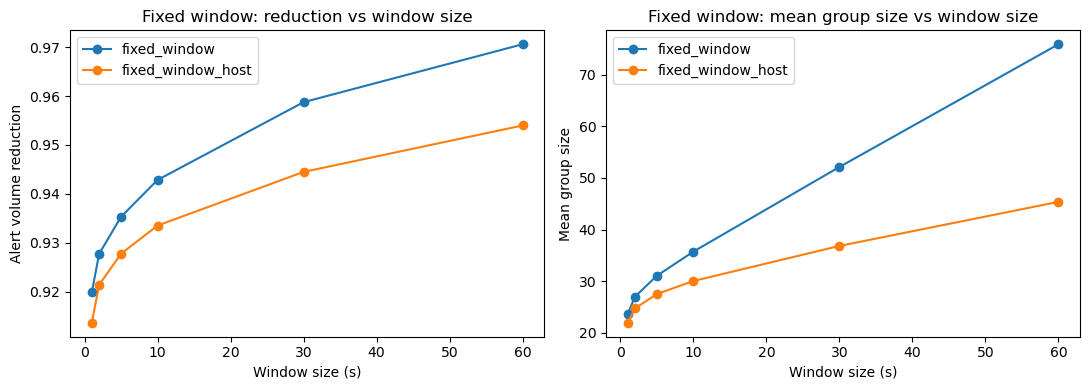

In [20]:
# Per-method diagnostic plot: reduction vs window size, split by host-split variant
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for method_name, group in fixed_window_df.groupby("method"):
    agg = group.groupby("param", as_index=False)["reduction"].mean()
    agg["param"] = agg["param"].astype(int)
    agg = agg.sort_values("param")
    ax[0].plot(agg["param"], agg["reduction"], marker="o", label=method_name)

ax[0].set_xlabel("Window size (s)")
ax[0].set_ylabel("Alert volume reduction")
ax[0].set_title("Fixed window: reduction vs window size")
ax[0].legend()

for method_name, group in fixed_window_df.groupby("method"):
    agg = group.groupby("param", as_index=False)["group_size_mean"].mean()
    agg["param"] = agg["param"].astype(int)
    agg = agg.sort_values("param")
    ax[1].plot(agg["param"], agg["group_size_mean"], marker="o", label=method_name)

ax[1].set_xlabel("Window size (s)")
ax[1].set_ylabel("Mean group size")
ax[1].set_title("Fixed window: mean group size vs window size")
ax[1].legend()

plt.tight_layout()
plt.show()


## 6. Time-delta

Log-scale sweep matching the original method's own validated evaluation
protocol: `delta = a * 2**i` for `i = -7 ... 13`, `a in {1, 1.5}`. This
range spans sub-second to multi-hour gaps, which matters specifically
because AIT-ADS alerts have whole-second timestamp resolution for many
detectors — a coarser, linear sweep would miss the discontinuity around
delta = 1s entirely.


In [21]:
def time_delta_grid():
    for a in (1.0, 1.5):
        for i in range(-7, 14):
            yield a * (2 ** i)

TIME_DELTA_VALUES = sorted(set(time_delta_grid()))
len(TIME_DELTA_VALUES), TIME_DELTA_VALUES[:5], TIME_DELTA_VALUES[-5:]


(42,
 [0.0078125, 0.01171875, 0.015625, 0.0234375, 0.03125],
 [3072.0, 4096.0, 6144.0, 8192.0, 12288.0])

In [22]:
time_delta_rows = []
for scenario in TEST_SCENARIOS:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    for delta in TIME_DELTA_VALUES:
        for fn, method_name in [
            (group_alerts_time_delta, "time_delta"),
            (group_alerts_time_delta_host, "time_delta_host"),
        ]:
            _start = time.perf_counter()
            records = fn(alerts, delta=delta)
            _elapsed = time.perf_counter() - _start
            row = run_method(
                method_name, f"{delta:.4f}", records, alerts, alert_index, scenario,
                inference_time_seconds=_elapsed,
            )
            time_delta_rows.append(row)

time_delta_df = pd.DataFrame(time_delta_rows)
time_delta_df["delta"] = time_delta_df["param"].astype(float)
time_delta_df.head()


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,mixed_frac,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario,delta
0,time_delta,0.0078,473104,0.974953,0.040575,39.924388,3.0,772,11850,0.926667,...,0.0,1.475781,1.0,15,0.0,0.0,0.0,0.0,fox,0.0078
1,time_delta_host,0.0078,473104,0.973023,0.040575,37.068401,3.0,772,12763,1.000000,...,0.0,1.504035,1.0,14,0.0,0.0,0.0,0.0,fox,0.0078
2,time_delta,0.0117,473104,0.974953,0.040575,39.924388,3.0,772,11850,0.926667,...,0.0,1.475781,1.0,15,0.0,0.0,0.0,0.0,fox,0.0117
3,time_delta_host,0.0117,473104,0.973023,0.040575,37.068401,3.0,772,12763,1.000000,...,0.0,1.504035,1.0,14,0.0,0.0,0.0,0.0,fox,0.0117
4,time_delta,0.0156,473104,0.974953,0.040575,39.924388,3.0,772,11850,0.926667,...,0.0,1.475781,1.0,15,0.0,0.0,0.0,0.0,fox,0.0156


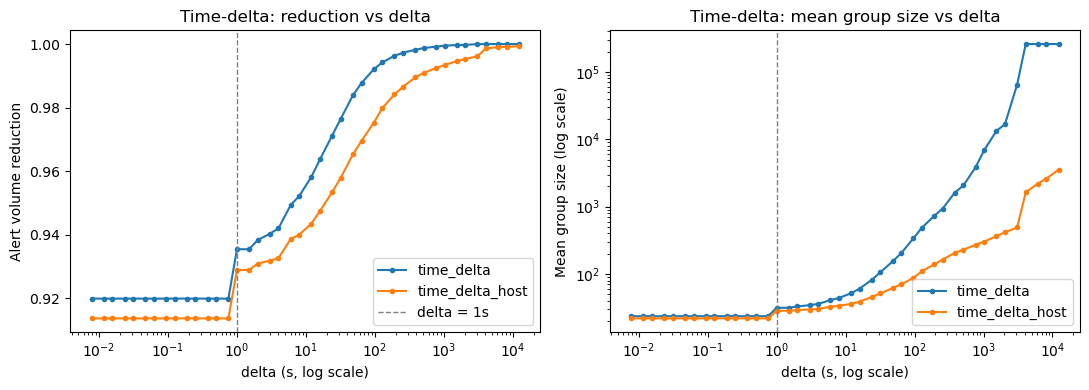

In [23]:
# Per-method diagnostic plot: log-x reduction curve, flags the delta=1s
# discontinuity described above.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for method_name, group in time_delta_df.groupby("method"):
    agg = group.groupby("delta", as_index=False)["reduction"].mean().sort_values("delta")
    ax[0].plot(agg["delta"], agg["reduction"], marker=".", label=method_name)

ax[0].set_xscale("log")
ax[0].axvline(1.0, color="grey", linestyle="--", linewidth=1, label="delta = 1s")
ax[0].set_xlabel("delta (s, log scale)")
ax[0].set_ylabel("Alert volume reduction")
ax[0].set_title("Time-delta: reduction vs delta")
ax[0].legend()

for method_name, group in time_delta_df.groupby("method"):
    agg = group.groupby("delta", as_index=False)["group_size_mean"].mean().sort_values("delta")
    ax[1].plot(agg["delta"], agg["group_size_mean"], marker=".", label=method_name)

ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].axvline(1.0, color="grey", linestyle="--", linewidth=1)
ax[1].set_xlabel("delta (s, log scale)")
ax[1].set_ylabel("Mean group size (log scale)")
ax[1].set_title("Time-delta: mean group size vs delta")
ax[1].legend()

plt.tight_layout()
plt.show()


## 7. CSCAS grouping

Single fixed configuration — the authors' own validated production
settings (SessionLength=300s, SessionTimeout=60s), not swept.


In [24]:
cscas_rows = []
for scenario in TEST_SCENARIOS:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    _start = time.perf_counter()
    records = group_alerts_cscas(
        alerts,
        session_length=CSCAS_SESSION_LENGTH_SECONDS,
        session_timeout=CSCAS_SESSION_TIMEOUT_SECONDS,
    )
    _elapsed = time.perf_counter() - _start
    row = run_method(
        "cscas_grouping",
        f"len={CSCAS_SESSION_LENGTH_SECONDS:.0f}_timeout={CSCAS_SESSION_TIMEOUT_SECONDS:.0f}",
        records, alerts, alert_index, scenario,
        inference_time_seconds=_elapsed,
    )
    cscas_rows.append(row)

cscas_df = pd.DataFrame(cscas_rows)
cscas_df


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,pure_attack_frac,mixed_frac,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario
0,cscas_grouping,len=300_timeout=60,473104,0.987121,0.040575,77.647136,4.0,98788,6093,1.0,...,0.043657,0.000164,1.0,1.0,1,22.787953,0.0,300.0,0.500000,fox
1,cscas_grouping,len=300_timeout=60,45544,0.901107,0.219217,10.111901,4.0,7068,4504,1.0,...,0.043961,0.000888,1.0,1.0,1,17.751110,0.0,300.0,0.318841,russellmitchell


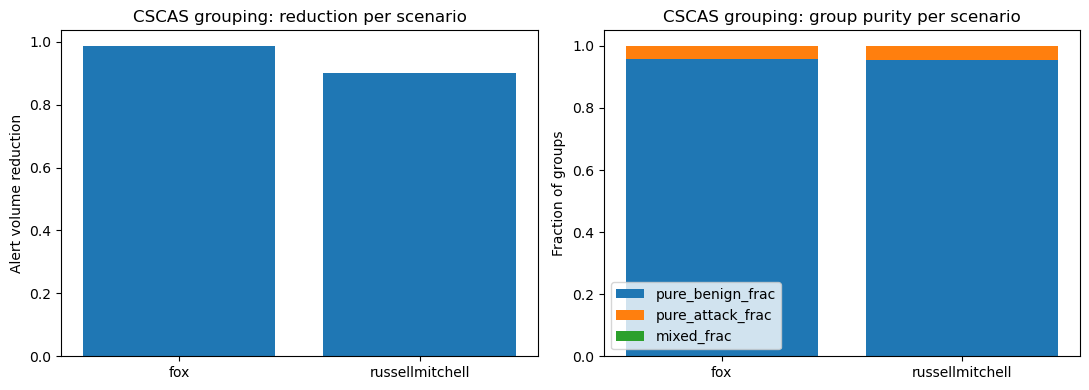

In [25]:
# Per-method diagnostic plot: reduction and purity per scenario (single config, so bars not curves)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(cscas_df["scenario"], cscas_df["reduction"])
ax[0].set_ylabel("Alert volume reduction")
ax[0].set_title("CSCAS grouping: reduction per scenario")

purity_cols = ["pure_benign_frac", "pure_attack_frac", "mixed_frac"]
bottom = np.zeros(len(cscas_df))
for col in purity_cols:
    ax[1].bar(cscas_df["scenario"], cscas_df[col], bottom=bottom, label=col)
    bottom += cscas_df[col].values
ax[1].set_ylabel("Fraction of groups")
ax[1].set_title("CSCAS grouping: group purity per scenario")
ax[1].legend()

plt.tight_layout()
plt.show()


### 7b. CSCAS sensitivity sweep (secondary)

The run above uses the authors' single validated production configuration
(`SessionLength=300s`, `SessionTimeout=60s`) as CSCAS's primary result --
that's the row that feeds `results_rows` and therefore the final
cross-method comparison in section 10.

This secondary sweep instead varies `session_timeout ∈ {30, 60, 120}` and
`session_length ∈ {150, 300, 600}` (9 combinations, both centered on the
authors' defaults) to show how sensitive CSCAS's numbers are to that
choice. It deliberately calls `evaluate(...)` directly instead of
`run_method(...)`, so these rows land only in `cscas_sensitivity_rows` /
`cscas_sensitivity_df` and never touch the shared `results_rows` /
`size_arrays` accumulators -- if they did, they'd compete with the primary
config for CSCAS's "best-reduction setting" slot in section 10's plots,
which would misrepresent CSCAS's operating point since the primary config
is a validated default, not something to cherry-pick against.


In [26]:
CSCAS_SENSITIVITY_TIMEOUTS = [30.0, 60.0, 120.0]
CSCAS_SENSITIVITY_LENGTHS = [150.0, 300.0, 600.0]

cscas_sensitivity_rows = []
for scenario in TEST_SCENARIOS:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    for session_timeout, session_length in itertools.product(
        CSCAS_SENSITIVITY_TIMEOUTS, CSCAS_SENSITIVITY_LENGTHS
    ):
        records = group_alerts_cscas(
            alerts, session_length=session_length, session_timeout=session_timeout
        )
        row, _sizes = evaluate(
            "cscas_grouping",
            f"len={session_length:.0f}_timeout={session_timeout:.0f}",
            records, alerts, alert_index,
        )
        row["scenario"] = scenario
        row["session_timeout"] = session_timeout
        row["session_length"] = session_length
        cscas_sensitivity_rows.append(row)

cscas_sensitivity_df = pd.DataFrame(cscas_sensitivity_rows)
cscas_sensitivity_df.head()


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario,session_timeout,session_length
0,cscas_grouping,len=150_timeout=30,473104,0.983972,0.040575,62.390083,3.0,49662,7583,1.0,...,1.0,1.0,1,9.879995,0.0,150.0,0.5,fox,30.0,150.0
1,cscas_grouping,len=300_timeout=30,473104,0.984067,0.040575,62.762536,3.0,98788,7538,1.0,...,1.0,1.0,1,10.005174,0.0,300.0,0.5,fox,30.0,300.0
2,cscas_grouping,len=600_timeout=30,473104,0.984107,0.040575,62.921133,3.0,195756,7519,1.0,...,1.0,1.0,1,10.049608,0.0,600.0,0.5,fox,30.0,600.0
3,cscas_grouping,len=150_timeout=60,473104,0.986641,0.040575,74.858228,4.0,49662,6320,1.0,...,1.0,1.0,1,20.871994,0.0,150.0,0.5,fox,60.0,150.0
4,cscas_grouping,len=300_timeout=60,473104,0.987121,0.040575,77.647136,4.0,98788,6093,1.0,...,1.0,1.0,1,22.787953,0.0,300.0,0.5,fox,60.0,300.0


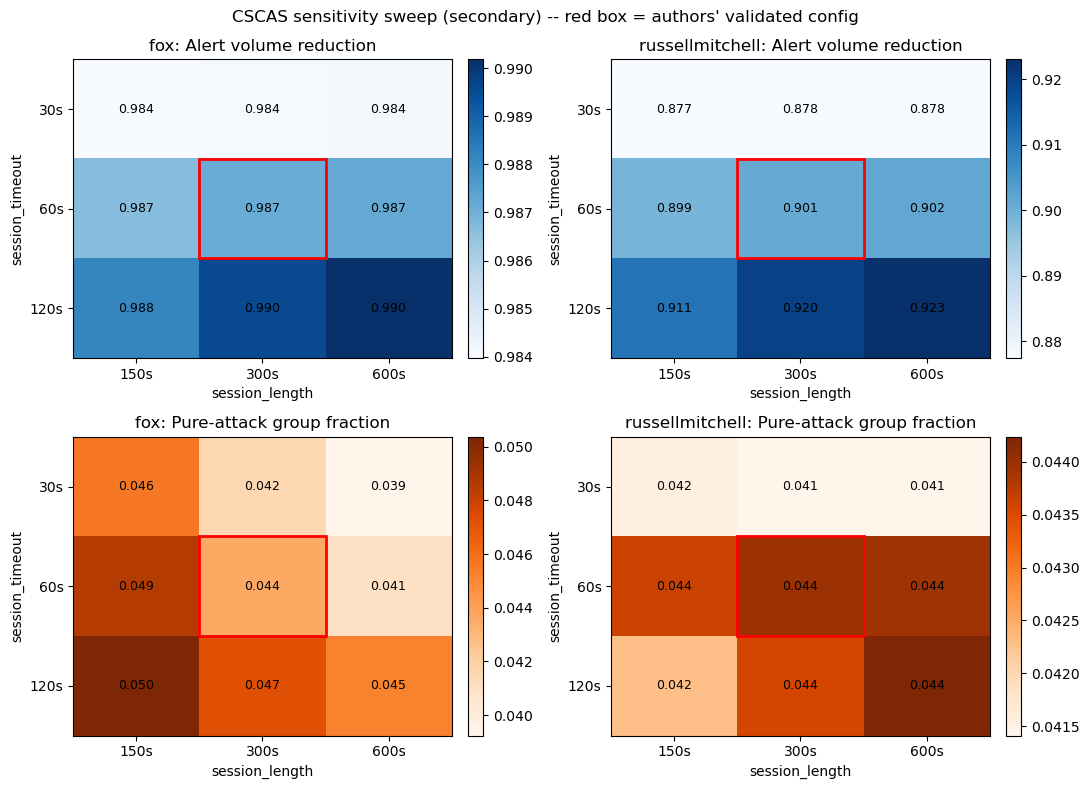

In [27]:
# Sensitivity diagnostic: reduction and attack purity over the
# (session_timeout, session_length) grid, one column per scenario.
n_scenarios = len(TEST_SCENARIOS)
fig, axes = plt.subplots(2, n_scenarios, figsize=(5.5 * n_scenarios, 8), squeeze=False)

for col, scenario in enumerate(TEST_SCENARIOS):
    scen_df = cscas_sensitivity_df[cscas_sensitivity_df["scenario"] == scenario]
    for row_idx, (metric, title, cmap) in enumerate([
        ("reduction", "Alert volume reduction", "Blues"),
        ("pure_attack_frac", "Pure-attack group fraction", "Oranges"),
    ]):
        pivot = scen_df.pivot(index="session_timeout", columns="session_length", values=metric)
        pivot = pivot.reindex(index=CSCAS_SENSITIVITY_TIMEOUTS, columns=CSCAS_SENSITIVITY_LENGTHS)
        ax = axes[row_idx, col]
        im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
        ax.set_xticks(range(len(CSCAS_SENSITIVITY_LENGTHS)))
        ax.set_xticklabels([f"{v:g}s" for v in CSCAS_SENSITIVITY_LENGTHS])
        ax.set_yticks(range(len(CSCAS_SENSITIVITY_TIMEOUTS)))
        ax.set_yticklabels([f"{v:g}s" for v in CSCAS_SENSITIVITY_TIMEOUTS])
        ax.set_xlabel("session_length")
        ax.set_ylabel("session_timeout")
        ax.set_title(f"{scenario}: {title}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Mark the authors' own validated configuration (len=300, timeout=60).
        if CSCAS_SESSION_LENGTH_SECONDS in CSCAS_SENSITIVITY_LENGTHS and (
            CSCAS_SESSION_TIMEOUT_SECONDS in CSCAS_SENSITIVITY_TIMEOUTS
        ):
            j0 = CSCAS_SENSITIVITY_LENGTHS.index(CSCAS_SESSION_LENGTH_SECONDS)
            i0 = CSCAS_SENSITIVITY_TIMEOUTS.index(CSCAS_SESSION_TIMEOUT_SECONDS)
            ax.add_patch(plt.Rectangle(
                (j0 - 0.5, i0 - 0.5), 1, 1, linewidth=2, edgecolor="red", facecolor="none",
            ))

fig.suptitle("CSCAS sensitivity sweep (secondary) -- red box = authors' validated config", fontsize=12)
plt.tight_layout()
plt.show()


## 8. AlertBERT

Delta and theta are swept separately, matching the AlertBERT paper's own
asymmetric design (`alertbert/eval_grouping.py`): delta only does cheap
pre-clustering in AlertBERT's algorithm (not the actual grouping signal),
so the paper swept it narrowly -- `alertbert_deltas` = `[1.5, 2.0, 3.0,
4.0, 6.0, 8.0, 12.0, 16.0, 24.0]`, reused verbatim here. Theta is the real
clustering-distance threshold, which the paper swept broadly
(`alertbert_theta_roc_traj_all` spans ~0.0078 to ~4096, close to
`TIME_DELTA_VALUES`'s own range); `ALERTBERT_THETAS` below is a coarser
7-value log-spaced subset of that same wide range rather than reusing the
narrow delta list, which would have collapsed that asymmetry. Pairs where
`theta < delta` are skipped -- `group_alerts_alertbert` raises on those
(theta is the max possible scaled cosine distance, so it must be >= delta).

This replaces an earlier, much larger 42-value log grid (`a * 2**i` for
`i` in `range(-7, 14)`, `a` in `(1, 1.5)`, applied identically to both
delta and theta) that produced ~900 valid pairs per scenario -- measured
at ~30s/pair (each pair re-embeds the whole scenario from scratch, no way
to reuse work across delta/theta the way DeepCASE reuses attention
vectors across eps), i.e. **~15 hours** for the full grid.

Uses the pretrained `mlm_1l_4h_16d_original_1_60k` checkpoint
(`external/AlertBERT/saved_models`) for inference only -- no training.
That checkpoint was trained on shaw/wardbeck/wheeler/wilson, so running it
on `TEST_SCENARIOS = ["fox", "russellmitchell"]` here evaluates it
**out-of-distribution**, same as every other method in this notebook is
evaluated on held-out scenarios -- kept this way deliberately for a fair
cross-method comparison; it is not the checkpoint's in-distribution setting.

**Requires the `thesis-alertbert` conda env** (now this notebook's default
kernel, "Python (thesis-alertbert)") -- `alertbert.models` hard-imports
`graph_tool` (conda/mamba-only, not in this repo's plain `venv/`). That
kernel already has `KMP_DUPLICATE_LIB_OK=TRUE` set (numpy/torch both
bundle libomp on macOS, which otherwise SIGABRTs on import). See
`thesis.grouping.alertbert_grouping`'s module docstring for details.

**Runtime note (measured):** ~30s per (delta, theta) pair. 9 deltas x 7
thetas gives 39 valid pairs per scenario (some `theta < delta` are
skipped) -- 78 calls total across both scenarios, **~39 minutes** for the
full grid. `RUN_FULL_ALERTBERT_SWEEP` below defaults to `False` and only
runs a handful of settings as a smoke test (~6 min); flip it to `True` for
the full grid.


In [28]:
# delta: the AlertBERT paper's own alertbert_deltas list
# (alertbert/eval_grouping.py) -- narrow on purpose, since delta only
# does cheap pre-clustering in AlertBERT's algorithm, not the actual
# grouping signal, so the paper didn't sweep it widely.
ALERTBERT_DELTAS = [1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 16.0, 24.0]

# theta: the real clustering-distance threshold -- the paper swept this
# broadly (alertbert_theta_roc_traj_all spans ~0.0078 to ~4096, matching
# TIME_DELTA_VALUES's range). This is a coarser log-spaced subset of that
# same wide range, not the narrow delta list -- reusing the delta list for
# theta too (an earlier version of this cell) collapsed that asymmetry.
ALERTBERT_THETAS = [0.25, 1.0, 4.0, 16.0, 64.0, 256.0, 1024.0]

# Every (delta, theta) pair with theta >= delta -- 39 pairs. Set to True
# to run the full sweep (see runtime note above); False runs a small
# smoke-test subset instead.
RUN_FULL_ALERTBERT_SWEEP = False

if RUN_FULL_ALERTBERT_SWEEP:
    alertbert_deltas = ALERTBERT_DELTAS
    alertbert_thetas = ALERTBERT_THETAS
else:
    alertbert_deltas = [2.0, 8.0, 24.0]
    alertbert_thetas = [4.0, 64.0, 1024.0]

alertbert_rows = []
for scenario in TEST_SCENARIOS:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    for delta in alertbert_deltas:
        for theta in alertbert_thetas:
            if theta < delta:
                continue
            _start = time.perf_counter()
            records = group_alerts_alertbert(alerts, delta=delta, theta=theta)
            _elapsed = time.perf_counter() - _start
            row = run_method(
                "alertbert", f"d={delta:.4f}_t={theta:.4f}", records, alerts, alert_index, scenario,
                inference_time_seconds=_elapsed,
            )
            alertbert_rows.append(row)

alertbert_df = pd.DataFrame(alertbert_rows)
alertbert_df.head()


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,pure_attack_frac,mixed_frac,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario
0,alertbert,d=2.0000_t=4.0000,473104,0.978861,0.040575,47.305669,3.0,821,10001,0.910909,...,0.138386,0.000100,1.377062,1.0,15,0.303170,0.0,2.0,0.5,fox
1,alertbert,d=2.0000_t=64.0000,473104,0.978592,0.040575,46.712480,3.0,821,10128,0.922492,...,0.143266,0.000099,1.362164,1.0,15,0.298973,0.0,2.0,0.5,fox
2,alertbert,d=2.0000_t=1024.0000,473104,0.973930,0.040575,38.357710,3.0,821,12334,0.973731,...,0.186963,0.000081,1.210962,1.0,9,0.280201,0.0,2.0,0.5,fox
3,alertbert,d=8.0000_t=64.0000,473104,0.984450,0.040575,64.306647,3.0,2917,7357,0.811880,...,0.066603,0.000136,1.421231,1.0,15,1.528476,0.0,8.0,0.5,fox
4,alertbert,d=8.0000_t=1024.0000,473104,0.983226,0.040575,59.614919,3.0,2917,7936,0.864919,...,0.077369,0.000126,1.406250,1.0,15,1.411542,0.0,8.0,0.5,fox


## 9. DeepCASE

Two-tier sweep, cost-ordered explicitly rather than a flat nested loop:
context length `L` (outer -- changes the ContextBuilder's input width and
attention size, so each value needs its own preprocessing pass and its
own training run) x DBSCAN `eps` (inner -- a clustering-only parameter
applied on top of one trained ContextBuilder's already-computed attention
vectors, via `group_alerts_deepcase_many_eps`, so it never retrains or
recomputes the attention-query optimization per eps). This means the real
cost is `len(DEEPCASE_CONTEXT_LENGTHS)` training runs per scenario, not
`len(DEEPCASE_CONTEXT_LENGTHS) * len(DEEPCASE_EPS_VALUES)`.

Fixed (not swept): `hidden_size=128` (default), `min_samples=5`,
`threshold=0.2` (the paper's confidence threshold `τ_confidence` -- the
library's own constructor default is different, so this is passed
explicitly rather than left at default), and a single fixed `seed=0` per
`L` (not averaged over multiple SGD training runs -- ContextBuilder
training is otherwise non-deterministic run to run).

Trained on `deepcase_train_alerts` (shaw/wardbeck/wheeler/wilson, see
Setup), evaluated on `TEST_SCENARIOS` (fox/russellmitchell) -- same
train/test discipline as everywhere else in this notebook.

**Outlier convention**: a sequence can fail to land in a DBSCAN cluster
for two different reasons -- the ContextBuilder wasn't confident enough
about it (below `threshold`), or DBSCAN itself calls it noise (`eps`/
`min_samples` too strict). DeepCASE's own library folds both into cluster
id `-1`. For comparability with the other four methods' metrics here, each
such alert becomes its own singleton group (`group_alerts_deepcase`'s
convention) -- the same way an alert with no time-neighbor becomes its own
one-alert group under time-delta. This is a modeling choice for *this*
comparison, not something DeepCASE's own paper needed (it routes outliers
to manual analyst review instead).

`group_id` stays `"deepcase:<anchor_alert_id>"` (not
`deepcase:{L}:{eps}:...`) -- consistent with every other method in this
notebook, which track their hyperparameter in the `param` column via
`run_method(...)` rather than baking it into `group_id`.

**Runtime (measured, not estimated)**: one full (`epochs=10`,
`cluster_iterations=100`) training + attention-query pass on the full
4-scenario train set (~1.4M alerts) took **~20 minutes** against `fox`
(~473k target alerts) -- and, measured separately, essentially the same
**~20 minutes** against `russellmitchell` too (~45k target alerts, ~10x
fewer), so target-scenario size does not meaningfully predict cost here
(likely because the attention-query step deduplicates identical context
sequences before processing). Training itself is a small fraction of
that (~90s for 2 epochs, measured separately) -- most of the ~20 min is
the `cluster_iterations` attention-query optimization.

The context-length list below was cut from 5 values (`[1, 2, 5, 10,
20]`, ~3+ hours for the full 5x2 grid) to 3 (`[2, 10, 20]` -- short/
medium/long coverage), since sweep breadth is the only real lever
(target scenario and, roughly, context length itself don't change the
per-run cost much). Full grid: `len(DEEPCASE_CONTEXT_LENGTHS) *
len(TEST_SCENARIOS)` = 6 runs x ~20 min = **~2 hours total**.
`RUN_FULL_DEEPCASE_SWEEP` below defaults to `False`, which only checks
the code path runs at all (1 scenario, 1 context length, `epochs=2`,
`cluster_iterations=5` -- a couple minutes, not a scientifically
meaningful result -- reducing `epochs` alone is not enough, since the
attention-query step dominates). Flip it to `True` for the full,
meaningful sweep and expect it to run for ~2 hours. Each trained
ContextBuilder is cached to `artifacts/cache/deepcase/` afterward (see
`thesis.grouping.deepcase_grouping`'s module docstring) so re-running the
same `(train_id, L, ..., seed, epochs)` combination later skips training
(though the attention-query step still runs fresh every call).


In [29]:
DEEPCASE_CONTEXT_LENGTHS_FULL = [2, 10, 20]  # short/medium/long, cut from 5 values
DEEPCASE_EPS_VALUES = [round(0.1 * i, 1) for i in range(1, 11)]

# ~20 min per (training + attention-query) run (measured, and confirmed
# not to scale down for the smaller russellmitchell target) x 3 lengths x
# 2 scenarios = ~2 hours for the full grid -- see runtime note above.
# False only checks the code path runs (1 scenario, 1 length, reduced
# epochs + cluster_iterations); True runs the full, scientifically
# meaningful sweep.
RUN_FULL_DEEPCASE_SWEEP = False

if RUN_FULL_DEEPCASE_SWEEP:
    deepcase_scenarios = TEST_SCENARIOS
    deepcase_context_lengths = DEEPCASE_CONTEXT_LENGTHS_FULL
    deepcase_epochs = 10
    deepcase_cluster_iterations = 100
else:
    deepcase_scenarios = TEST_SCENARIOS[:1]
    deepcase_context_lengths = [2]
    deepcase_epochs = 2
    # cluster_iterations (the attention-query optimization step) is the
    # real bottleneck, not epochs -- reducing epochs alone leaves a
    # ~15-20 minute smoke test since it still runs 100 iterations over
    # every target alert.
    deepcase_cluster_iterations = 5

deepcase_rows = []
for scenario in deepcase_scenarios:
    alerts = alerts_by_scenario[scenario]
    alert_index = alert_index_by_scenario[scenario]
    for L in deepcase_context_lengths:
        _start = time.perf_counter()
        results_by_eps = group_alerts_deepcase_many_eps(
            alerts,
            train_alerts=deepcase_train_alerts,
            train_id=DEEPCASE_TRAIN_ID,
            eps_values=DEEPCASE_EPS_VALUES,
            context_length=L,
            min_samples=5,
            threshold=0.2,
            seed=0,
            epochs=deepcase_epochs,
            cluster_iterations=deepcase_cluster_iterations,
        )
        # Shared cost across every eps value in this call for this
        # (scenario, L) pair -- logged identically on each resulting row
        # rather than divided among them, since training only happens once.
        _elapsed = time.perf_counter() - _start
        for eps, records in results_by_eps.items():
            row = run_method(
                "deepcase", f"L={L}_eps={eps:.1f}", records, alerts, alert_index, scenario,
                train_time_seconds=_elapsed,
            )
            deepcase_rows.append(row)

deepcase_df = pd.DataFrame(deepcase_rows)
deepcase_df["context_length"] = deepcase_df["param"].str.extract(r"L=(\d+)").astype(int)
deepcase_df["eps"] = deepcase_df["param"].str.extract(r"eps=([\d.]+)").astype(float)
deepcase_df.head()


[Epoch 2/2 loss=0.2058]: 100%|██████████| 11035/11035 [01:00<00:00, 181.80it/s]


,method,param,n_raw_alerts,reduction,coverage,group_size_mean,group_size_median,group_size_max,n_groups,host_purity,...,signature_diversity_mean,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario,context_length,eps
0,deepcase,L=2_eps=0.1,473104,0.987227,0.040575,78.289591,1.0,376749,6043,0.985603,...,1.000827,1.0,3,4520.487010,0.0,422574.0,0.003562,fox,2,0.1
1,deepcase,L=2_eps=0.2,473104,0.987269,0.040575,78.549560,1.0,376749,6023,0.987216,...,1.000830,1.0,3,3996.408766,0.0,422574.0,0.003562,fox,2,0.2
2,deepcase,L=2_eps=0.3,473104,0.987333,0.040575,78.942767,1.0,376705,5993,0.986985,...,1.000834,1.0,3,4027.766561,0.0,422574.0,0.003583,fox,2,0.3
3,deepcase,L=2_eps=0.4,473104,0.987396,0.040575,79.339930,1.0,376705,5963,0.988429,...,1.000671,1.0,4,3537.560456,0.0,422574.0,0.003580,fox,2,0.4
4,deepcase,L=2_eps=0.5,473104,0.987512,0.040575,80.078538,1.0,376705,5908,0.990521,...,1.000677,1.0,4,2958.342925,0.0,428105.0,0.003587,fox,2,0.5


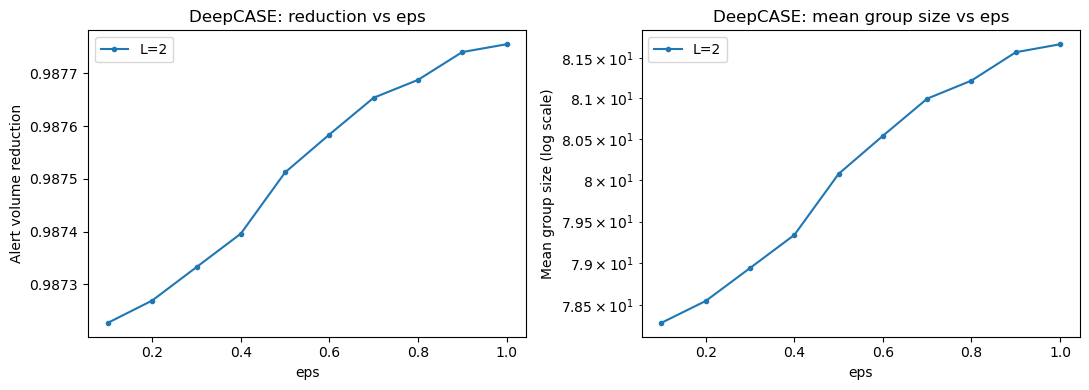

In [30]:
# Per-method diagnostic plot: reduction and mean group size vs eps, one
# line per context length L.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for L, group in deepcase_df.groupby("context_length"):
    agg = group.groupby("eps", as_index=False)["reduction"].mean().sort_values("eps")
    ax[0].plot(agg["eps"], agg["reduction"], marker=".", label=f"L={L}")

ax[0].set_xlabel("eps")
ax[0].set_ylabel("Alert volume reduction")
ax[0].set_title("DeepCASE: reduction vs eps")
ax[0].legend()

for L, group in deepcase_df.groupby("context_length"):
    agg = group.groupby("eps", as_index=False)["group_size_mean"].mean().sort_values("eps")
    ax[1].plot(agg["eps"], agg["group_size_mean"], marker=".", label=f"L={L}")

ax[1].set_yscale("log")
ax[1].set_xlabel("eps")
ax[1].set_ylabel("Mean group size (log scale)")
ax[1].set_title("DeepCASE: mean group size vs eps")
ax[1].legend()

plt.tight_layout()
plt.show()


## 10. Combined results and final comparison plots

Everything appended to `results_rows` across all sections above,
combined into one DataFrame.


In [31]:
all_results_df = pd.DataFrame(results_rows)
all_results_df.to_csv("grouping_comparison_results.csv", index=False)
all_results_df.groupby("method")[[
    "reduction", "coverage", "group_size_mean", "n_groups",
    "pure_benign_frac", "pure_attack_frac", "mixed_frac",
    "host_purity", "signature_diversity_mean", "temporal_span_mean",
    "minority_label_exposure", "train_time_seconds", "inference_time_seconds",
]].mean()


,reduction,coverage,group_size_mean,n_groups,pure_benign_frac,pure_attack_frac,mixed_frac,host_purity,signature_diversity_mean,temporal_span_mean,minority_label_exposure,train_time_seconds,inference_time_seconds
method,,,,,,,,,,,,,
alertbert,0.937821,0.129896,37.253966,6537.642857,0.931528,0.068332,0.000140,0.860674,1.422667,2.443884,0.290179,NaN,49.476896
cscas_grouping,0.944114,0.129896,43.879518,5298.500000,0.955665,0.043809,0.000526,1.000000,1.000000,20.269532,0.409420,NaN,1.194560
deepcase,0.987516,0.040575,80.119697,5906.300000,0.491875,0.502359,0.005766,0.990704,1.000727,2926.412725,0.003750,157.282091,NaN
fixed_window,0.942503,0.129896,40.906919,6204.583333,0.956497,0.043382,0.000121,0.811010,1.570445,4.215183,0.073810,NaN,0.328737
fixed_window_host,0.932446,0.129896,31.081255,7360.166667,0.952113,0.047864,0.000023,1.000000,1.463302,2.188384,0.041667,NaN,0.361525
time_delta,0.959199,0.129896,27390.133171,4452.940476,0.856638,0.036840,0.106522,0.611501,10.154303,40474.356323,0.128821,NaN,0.693839
time_delta_host,0.950781,0.129896,324.320653,5393.357143,0.937412,0.049216,0.013371,1.000000,2.003711,2756.918284,0.151148,NaN,0.751462


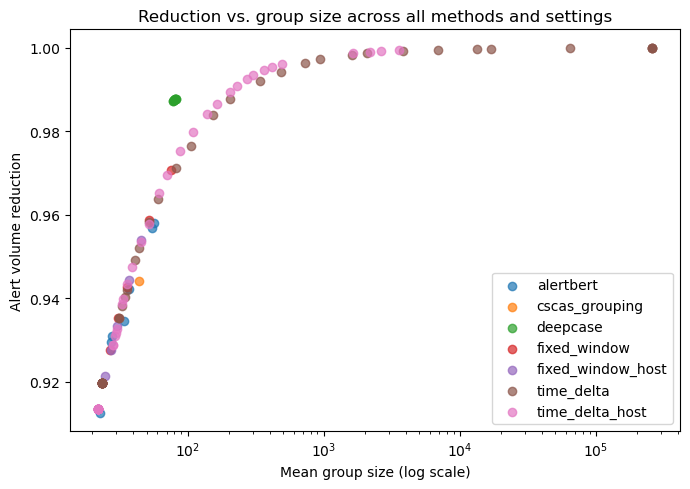

In [32]:
# Final plot 1: reduction vs mean group size, all methods overlaid.
# This is the key tradeoff plot -- high reduction from one giant group is
# not the same achievement as high reduction from many well-formed groups.
fig, ax = plt.subplots(figsize=(7, 5))

for method_name, group in all_results_df.groupby("method"):
    agg = group.groupby("param", as_index=False)[["reduction", "group_size_mean"]].mean()
    ax.scatter(agg["group_size_mean"], agg["reduction"], label=method_name, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("Mean group size (log scale)")
ax.set_ylabel("Alert volume reduction")
ax.set_title("Reduction vs. group size across all methods and settings")
ax.legend()
plt.tight_layout()
plt.show()


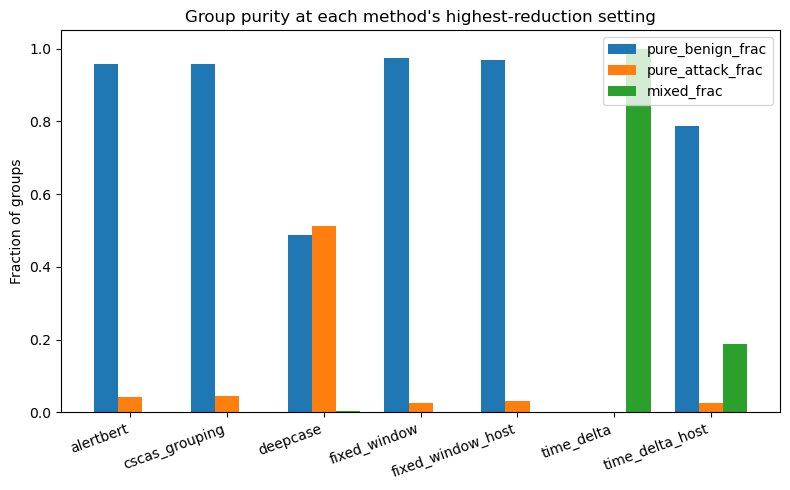

In [33]:
# Final plot 2: purity comparison at each method's best-reduction setting
# (or its only setting, for CSCAS). Pick the operating point per method,
# then compare purity fractions side by side.
best_settings = (
    all_results_df.sort_values("reduction", ascending=False)
    .groupby("method", as_index=False)
    .first()
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(best_settings))
width = 0.25

for i, col in enumerate(["pure_benign_frac", "pure_attack_frac", "mixed_frac"]):
    ax.bar(x + i * width, best_settings[col], width=width, label=col)

ax.set_xticks(x + width)
ax.set_xticklabels(best_settings["method"], rotation=20, ha="right")
ax.set_ylabel("Fraction of groups")
ax.set_title("Group purity at each method's highest-reduction setting")
ax.legend()
plt.tight_layout()
plt.show()


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_5557/3845936034.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)


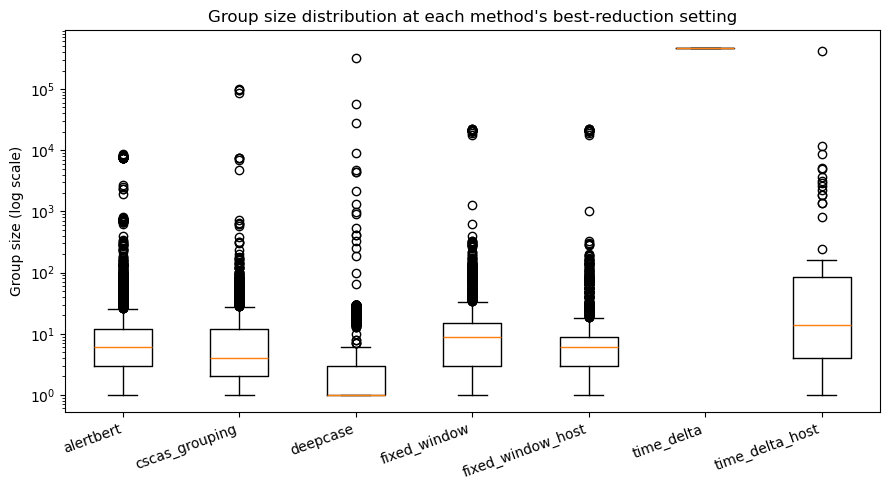

In [34]:
# Final plot 3: group size distributions side by side (log-y boxplot) at
# each method's best-reduction setting -- surfaces the runaway-group
# pathology (long streams of dense, repetitive alerts collapsing into a
# single giant group) that flat mean/median stats can hide.
fig, ax = plt.subplots(figsize=(9, 5))

box_data = []
labels = []
for _, row in best_settings.iterrows():
    key = (row["method"], row["param"], row["scenario"])
    if key in size_arrays:
        box_data.append(size_arrays[key])
        labels.append(row["method"])

ax.boxplot(box_data, labels=labels, showfliers=True)
ax.set_yscale("log")
ax.set_ylabel("Group size (log scale)")
ax.set_title("Group size distribution at each method's best-reduction setting")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
